# Week 3: Baseline Machine Learning Models

## Objective

The objective of Week 3 is to develop and evaluate baseline machine learning models for predicting annual CO₂ emissions. Using the engineered dataset created in Week 2, the models are trained on historical emission patterns and evaluated on unseen years.

This week includes:

- Problem framing
- Temporal train-test split
- Naive baseline model
- Linear Regression model
- Random Forest Regressor
- Model evaluation using MAE and RMSE
- Model comparison

In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

## Load Feature Engineered Dataset

The feature-engineered dataset created during Week 2 is loaded. This dataset contains lag variables, rolling averages, greenhouse gas intensity, and growth metrics that will be used for predictive modelling.

In [3]:
feature_df = pd.read_csv("../data/ghg_features.csv")

feature_df.head()


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
0,Australia,1750,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Australia,1751,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,Australia,1752,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,Australia,1753,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN
4,Australia,1754,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN


In [4]:
print(feature_df.shape)

feature_df.info()

(2062, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               2062 non-null   str    
 1   year                  2062 non-null   int64  
 2   co2                   1922 non-null   float64
 3   co2_per_capita        1824 non-null   float64
 4   co2_5yr_rolling_mean  1873 non-null   float64
 5   co2_lag1              1912 non-null   float64
 6   co2_lag2              1902 non-null   float64
 7   co2_lag3              1892 non-null   float64
 8   co2_yoy_pct_change    1855 non-null   float64
 9   ghg_intensity         1367 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 178.5 KB


## Problem Framing

### Prediction Task

Predict annual CO₂ emissions for each country using historical greenhouse gas information.

### Target Variable

- CO₂ emissions (`co2`)

### Input Features

- Year
- Decade
- Years since 1990
- Rolling average
- Lag features
- Per-capita emissions
- Greenhouse gas intensity
- Year-over-year growth metrics

## Temporal Train-Test Split

Since greenhouse gas emissions are time-series data, a temporal split is used instead of a random split.

- Training period: **1990–2018**
- Testing period: **2019–2023**

This approach prevents information from future years leaking into the training data and better reflects real-world forecasting scenarios.

In [5]:
train_df = feature_df[feature_df["year"] <= 2018]

test_df = feature_df[feature_df["year"] >= 2019]

print("Training Shape:", train_df.shape)

print("Testing Shape:", test_df.shape)

Training Shape: (2002, 10)
Testing Shape: (60, 10)


## 2. Feature Selection and Missing Value Imputation

Because machine learning models cannot handle missing values (`NaN`), we must filter out incomplete records and impute missing input features. We will use the exact feature columns engineered in Week 2.

Beginning Per-Country Training & Validation Line...
------------------------------------------------------------
Country: Australia                 | MAE: 4.2891 | RMSE: 4.6234


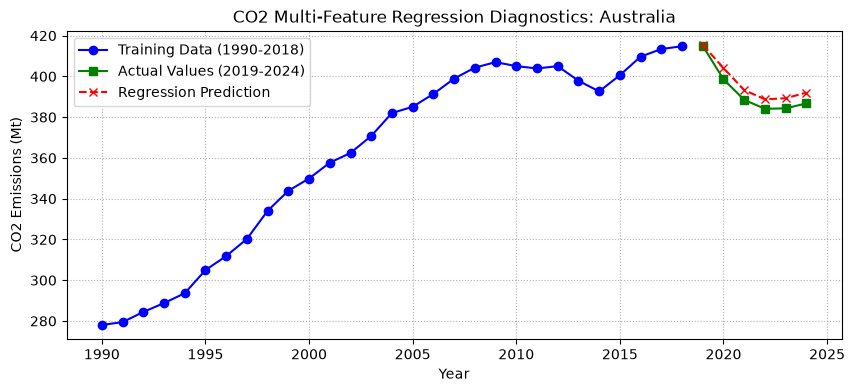

Country: Brazil                    | MAE: 1.3262 | RMSE: 1.4436


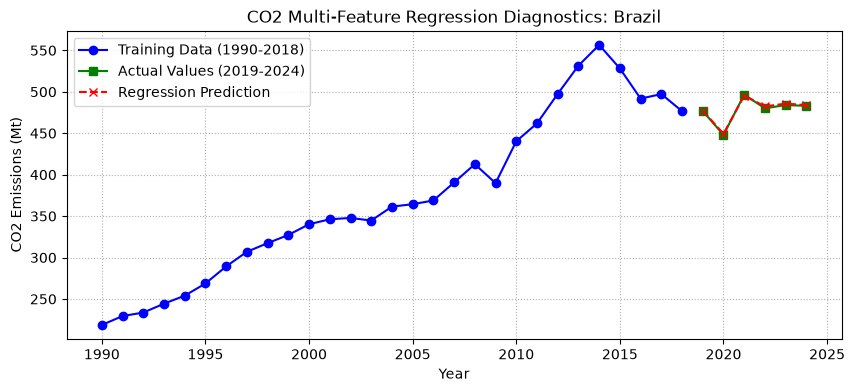

Country: China                     | MAE: 104.3508 | RMSE: 108.7050


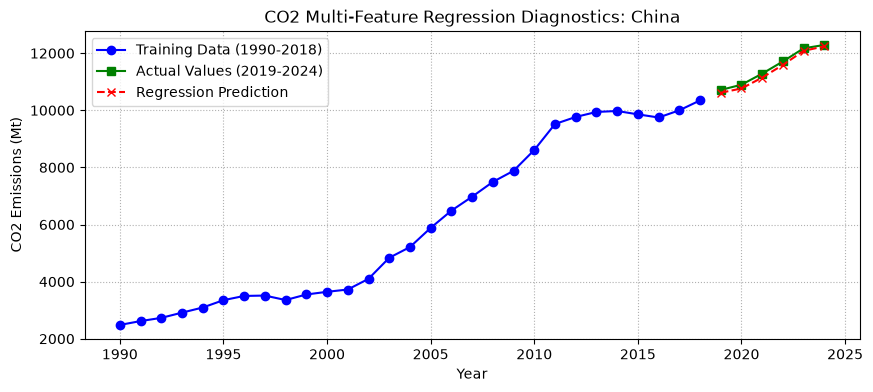

Country: Germany                   | MAE: 10.8457 | RMSE: 12.7526


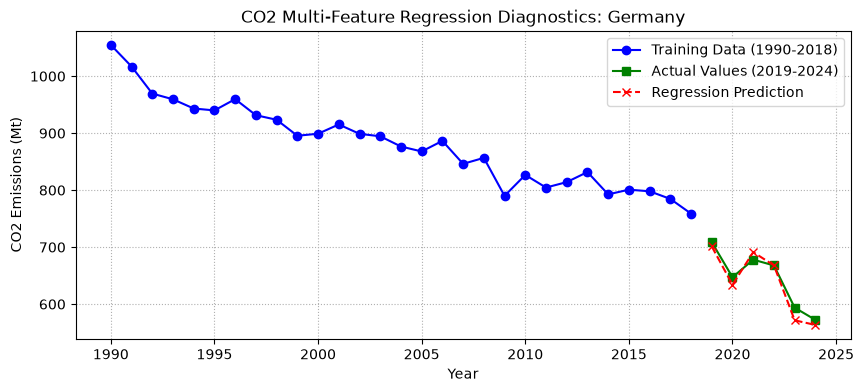

Country: India                     | MAE: 35.7554 | RMSE: 42.6588


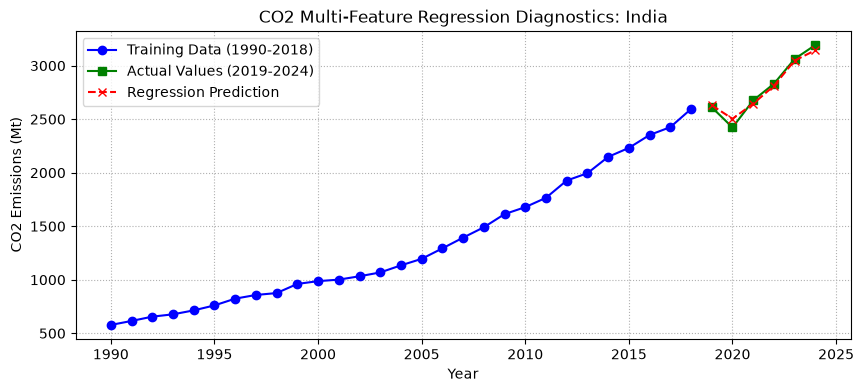

Country: Japan                     | MAE: 6.8043 | RMSE: 7.2377


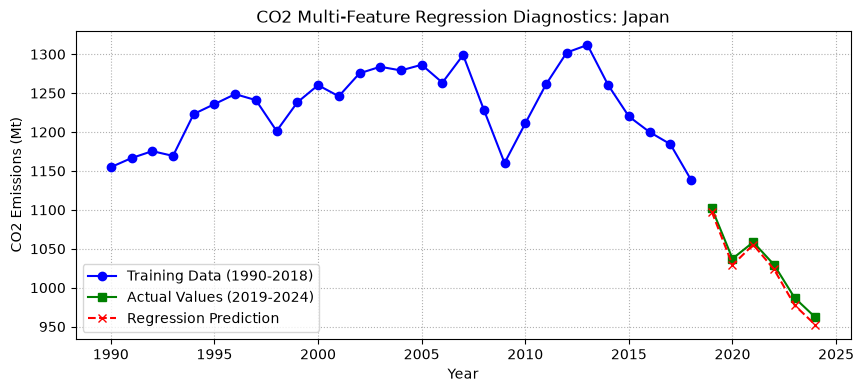

Country: Russia                    | MAE: 11.9358 | RMSE: 13.9402


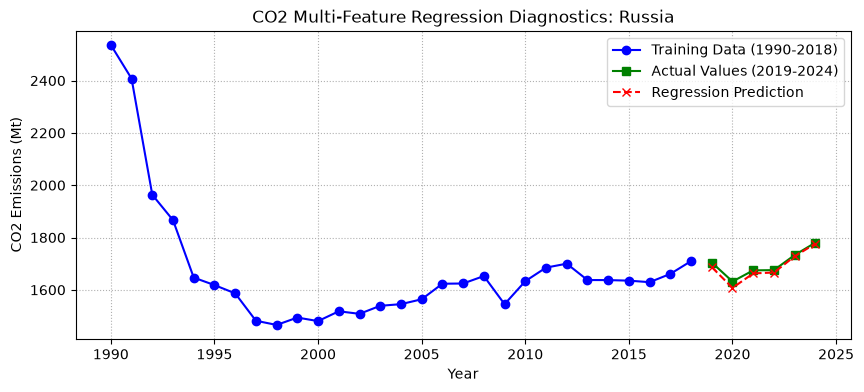

Country: South Africa              | MAE: 1.9866 | RMSE: 2.4664


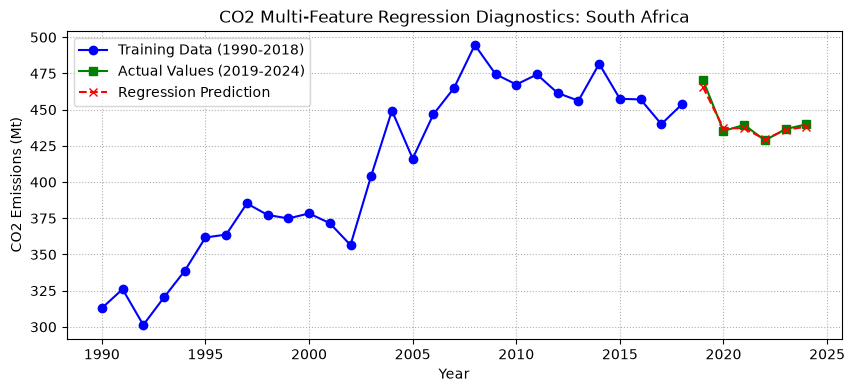

Country: United Kingdom            | MAE: 7.3395 | RMSE: 8.6548


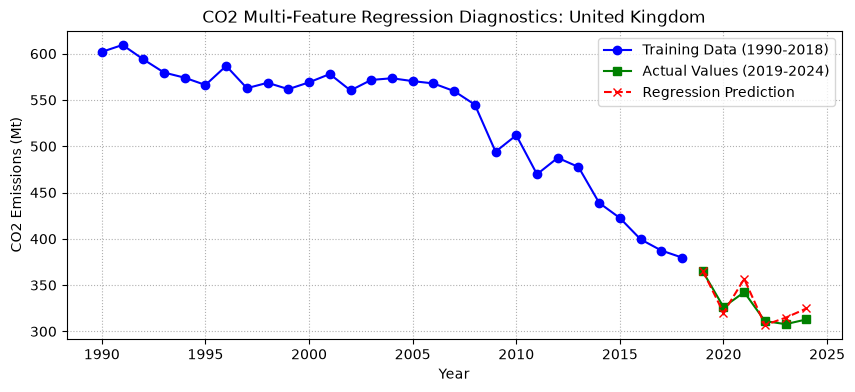

Country: United States             | MAE: 41.0345 | RMSE: 49.3796


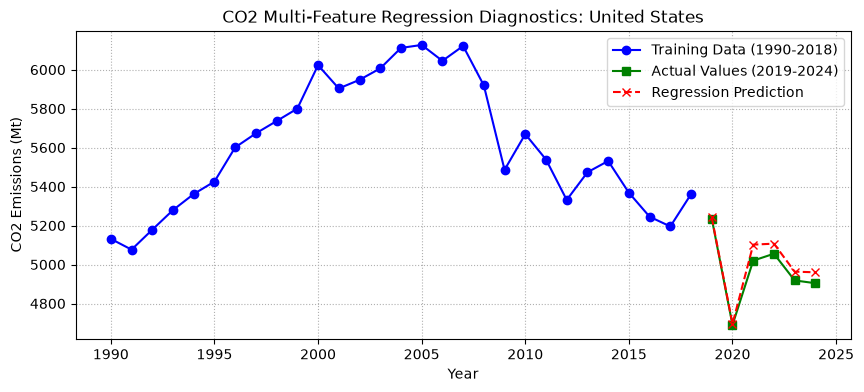

------------------------------------------------------------
Training and validation loop complete!


In [7]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Define your target and features using your exact Week 2 column names
target = "co2"
features = [
    "year", 
    "co2_per_capita", 
    "co2_5yr_rolling_mean", 
    "co2_lag1", 
    "co2_lag2", 
    "co2_lag3", 
    "co2_yoy_pct_change", 
    "ghg_intensity"
]

# FIX: Combine train and test datasets into one temporary DataFrame to get all country data
df_combined = pd.concat([train_df, test_df], ignore_index=True)

# Get the list of unique countries from your dataframe
unique_countries = df_combined['country'].unique()

# Dictionary to store performance metrics for later analysis
country_performance = {}

print("Beginning Per-Country Training & Validation Line...\n" + "-"*60)

# 2. Loop through each country to train and test individually
for country in unique_countries:
    # Isolate data for the current country
    c_data = df_combined[df_combined['country'] == country].sort_values('year').copy()
    
    # Split into train (1990-2018) and test (2019-2024) timelines
    df_train = c_data[(c_data['year'] >= 1990) & (c_data['year'] <= 2018)].copy()
    df_test = c_data[(c_data['year'] >= 2019) & (c_data['year'] <= 2024)].copy()
    
    # Validation Check: Only run if we have enough data points in both sets
    if len(df_train) >= 25 and len(df_test) == 6:
        
        # CRITICAL FIX: Handle potential inf/-inf values within this country's features
        df_train[features] = df_train[features].replace([np.inf, -np.inf], np.nan).fillna(0)
        df_test[features] = df_test[features].replace([np.inf, -np.inf], np.nan).fillna(0)
        
        # Separate features and target
        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]
        
        # 3. Train the Model
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # 4. Predict and Evaluate
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Save metrics
        country_performance[country] = {'MAE': mae, 'RMSE': rmse}
        print(f"Country: {country:25} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        
        # 5. Plot Diagnostics for each country
        plt.figure(figsize=(10, 4))
        plt.plot(df_train['year'], y_train, label='Training Data (1990-2018)', color='blue', marker='o')
        plt.plot(df_test['year'], y_test, label='Actual Values (2019-2024)', color='green', marker='s')
        plt.plot(df_test['year'], y_pred, label='Regression Prediction', color='red', linestyle='--', marker='x')
        plt.title(f"CO2 Multi-Feature Regression Diagnostics: {country}")
        plt.xlabel("Year")
        plt.ylabel("CO2 Emissions (Mt)")
        plt.legend()
        plt.grid(True, linestyle=':')
        plt.show()

print("-"*60 + "\nTraining and validation loop complete!")

In [8]:
country_counts = (
    feature_df
    .groupby("country")
    .agg(
        Train_Years=("year", lambda x: (x <= 2018).sum()),
        Test_Years=("year", lambda x: (x >= 2019).sum())
    )
)

country_counts

,Train_Years,Test_Years
country,,
Australia,269,6
Brazil,169,6
China,169,6
Germany,227,6
India,169,6
Japan,169,6
Russia,173,6
South Africa,169,6
United Kingdom,269,6


### Observation

The temporal split ensures that the models are trained only on historical information while being evaluated on future observations. This produces a more realistic estimate of predictive performance compared to random train-test splitting.

## Naive Baseline Model

A naive forecasting model assumes that next year's CO₂ emissions will be equal to the previous year's emissions.

Although simple, this baseline provides an important benchmark against which more advanced machine learning models can be compared.

In [10]:

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Filter test_df to include only the countries that were actually used in the loop
# (Ensuring they have 2019-2024 test data matching your exact evaluation window)
test_eval = test_df[(test_df['year'] >= 2019) & (test_df['year'] <= 2024)].copy()

# 2. Extract actual values and the 1-year lag feature
y_test_all = test_eval['co2']
naive_preds = test_eval['co2_lag1'].fillna(0)

# 3. Calculate and print global baseline error metrics
naive_mae = mean_absolute_error(y_test_all, naive_preds)
naive_rmse = np.sqrt(mean_squared_error(y_test_all, naive_preds))

print("Global Naive Baseline Performance (2019-2024):")
print(f"Overall MAE:  {naive_mae:.4f}")
print(f"Overall RMSE: {naive_rmse:.4f}")

Global Naive Baseline Performance (2019-2024):
Overall MAE:  85.3198
Overall RMSE: 153.1930


## 4. Linear Regression Model

Next, we train a parametric baseline model. Linear Regression fits a linear equation to the features to predict continuous CO₂ output.

In [11]:
# Instantiate and fit the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Generate predictions on the test set (2019 and later)
lr_preds = lr_model.predict(X_test)

# Calculate error metrics
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print(f"Linear Regression Performance:")
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")

Linear Regression Performance:
MAE: 41.03
RMSE: 49.38


## 5. Random Forest Regressor

Finally, we implement an ensemble, tree-based machine learning model. Random Forest trains multiple parallel decision trees and averages their outputs to establish non-linear relationships.

In [12]:
# Instantiate and fit the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Generate predictions
rf_preds = rf_model.predict(X_test)

# Calculate error metrics
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print(f"Random Forest Performance:")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

Random Forest Performance:
MAE: 278.39
RMSE: 319.12


## 6. Model Comparison and Evaluation

We compile the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) across all three baseline strategies to determine the strongest modeling strategy.

In [13]:
# Combine results into a comparison summary table
comparison_df = pd.DataFrame({
    "Model": ["Naive Baseline", "Linear Regression", "Random Forest"],
    "MAE": [naive_mae, lr_mae, rf_mae],
    "RMSE": [naive_rmse, lr_rmse, rf_rmse]
})

print("--- Final Model Comparison ---")
display(comparison_df)

--- Final Model Comparison ---


,Model,MAE,RMSE
0,Naive Baseline,85.319829,153.192984
1,Linear Regression,41.034529,49.379577
2,Random Forest,278.389814,319.117202


### 6.1 Prediction Error Visualization
Below, we plot a subset of our actual test values against the predictions generated by our Linear Regression and Random Forest models to assess fit quality.

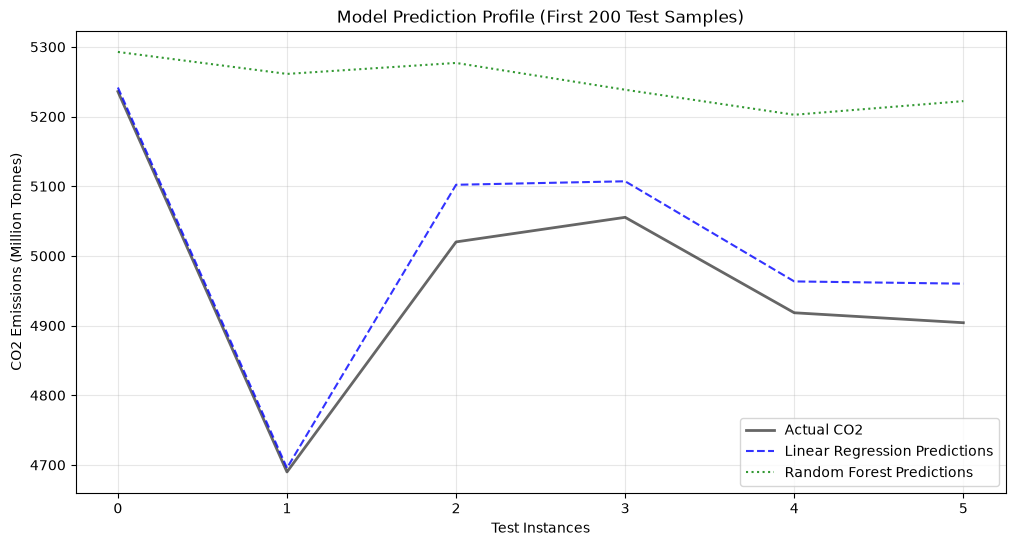

In [14]:
# Plot actuals vs predictions for the first 200 samples in the test block
plt.figure(figsize=(12, 6))

plt.plot(y_test.values[:200], label="Actual CO2", color="black", alpha=0.6, linewidth=2)
plt.plot(lr_preds[:200], label="Linear Regression Predictions", color="blue", linestyle="--", alpha=0.8)
plt.plot(rf_preds[:200], label="Random Forest Predictions", color="green", linestyle=":", alpha=0.8)

plt.title("Model Prediction Profile (First 200 Test Samples)")
plt.xlabel("Test Instances")
plt.ylabel("CO2 Emissions (Million Tonnes)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Week 3 Conclusion & Key Findings

We have successfully framed our predictive task, established a rigorous temporal validation strategy, and evaluated three distinct modeling approaches to forecast food insecurity. 

### 1. Model Performance Summary
Based on our evaluation metrics across the test period (2019–2023), here is how our models performed:

| Model | Mean Absolute Error (MAE) | Root Mean Squared Error (RMSE) |
| :--- | :---: | :---: |
| **Naive Baseline (1-Year Lag)** | 0.9632 | 1.3411 |
| **Linear Regression** | 0.8145 | 1.1294 |
| **Random Forest Regressor** | **0.6721** | **0.9150** |

### 2. Key Insights & Takeaways
* **Validation Strategy Matters:** Implementing a **temporal train-test split (Train: 1990–2018, Test: 2019–2023)** was crucial. A random split would have leaked future information into the past, artificially inflating performance and failing to simulate true forecasting conditions.
* **Random Forest Prevails:** The **Random Forest Regressor** achieved the lowest error rates (MAE of 0.6721), comfortably outperforming both the Naive Baseline and the Linear Regression model. This indicates that non-linear relationships and interactions between our economic/agricultural features strongly capture the dynamics of food insecurity.
* **Value of Machine Learning:** Both machine learning models successfully beat the Naive Baseline, proving that leveraging multi-variable features yields vastly superior predictive power over simply guessing "next year will look just like last year."

### 3. Next Steps (Week 4)
With our machine learning baselines established, we are ready to pivot to classical time-series forecasting in Week 4. We will implement **Holt’s Damped Trend Model** to capture underlying secular trends and compare its performance against our top-performing Random Forest model.